In [ ]:
!pip install -U sentence-transformers

from sentence_transformers import SentenceTransformer, util

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
# Step 1: Load the CSV file into a DataFrame
#df = pd.read_csv('/content/drive/My Drive/overview-of-recordings.csv')
df = pd.read_csv('https://www.dropbox.com/scl/fi/qvzhk2zp8f2wpnz7hrqyd/overview-of-recordings.csv?rlkey=vugax3x2k76botbpberqbqzve&st=9omelcyw&dl=1')

df.head(10)

,audio_clipping,audio_clipping:confidence,background_noise_audible,background_noise_audible:confidence,overall_quality_of_the_audio,quiet_speaker,quiet_speaker:confidence,speaker_id,file_download,file_name,phrase,prompt,writer_id
0,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,43453425,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43453425_58166571.wav,When I remember her I feel down,Emotional pain,21665495
1,light_clipping,0.6803,no_noise,0.6803,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_43347848.wav,When I carry heavy things I feel like breaking...,Hair falling out,44088126
2,no_clipping,1.0000,no_noise,0.6655,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_53187202.wav,there is too much pain when i move my arm,Heart hurts,44292353
3,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,31349958,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_31349958_55816195.wav,My son had his lip pierced and it is swollen a...,Infected wound,43755034
4,no_clipping,1.0000,no_noise,1.0000,4.67,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_82524191.wav,My muscles in my lower back are aching,Infected wound,21665495
5,no_clipping,1.0000,no_noise,1.0000,3.00,audible_speaker,1.0,40663048,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_40663048_51348478.wav,i have muscle pain that my back\nI Have Muscle...,Foot ache,44130352
6,no_clipping,1.0000,no_noise,1.0000,3.67,audible_speaker,1.0,40663048,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_40663048_42741720.wav,I have muscle pain in my left leg,Shoulder pain,43913997
7,no_clipping,1.0000,no_noise,1.0000,4.25,audible_speaker,1.0,15004831,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_15004831_21919890.wav,I have cut my finger because of playing footba...,Injury from sports,43318517
8,no_clipping,0.6978,no_noise,1.0000,3.67,audible_speaker,1.0,14353703,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_14353703_93481996.wav,I have acne in my face and other problems in m...,Skin issue,44066678
9,no_clipping,1.0000,no_noise,0.6879,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_85316490.wav,I have a strange rash on my arm,Foot ache,44130352


In [ ]:
# Drop all columns except 'phrase' and 'prompt'
df = df[['phrase', 'prompt']]

# Display the DataFrame
print(df.head(10))

                                              phrase              prompt
0                    When I remember her I feel down      Emotional pain
1  When I carry heavy things I feel like breaking...    Hair falling out
2          there is too much pain when i move my arm         Heart hurts
3  My son had his lip pierced and it is swollen a...      Infected wound
4             My muscles in my lower back are aching      Infected wound
5  i have muscle pain that my back\nI Have Muscle...           Foot ache
6                  I have muscle pain in my left leg       Shoulder pain
7  I have cut my finger because of playing footba...  Injury from sports
8  I have acne in my face and other problems in m...          Skin issue
9                    I have a strange rash on my arm           Foot ache


In [ ]:
# Check if there are any empty values in the 'phrase' column
empty_phrase = df['phrase'].isna().any()

# Check if there are any empty values in the 'prompt' column
empty_prompt = df['prompt'].isna().any()

# Print the results
if empty_phrase:
    print("There are empty values in the 'phrase' column.")
else:
    print("There are no empty values in the 'phrase' column.")

if empty_prompt:
    print("There are empty values in the 'prompt' column.")
else:
    print("There are no empty values in the 'prompt' column.")

There are no empty values in the 'phrase' column.
There are no empty values in the 'prompt' column.


In [ ]:
num_rows = len(df)
print("Number of rows:", num_rows)

Number of rows: 6661


In [ ]:
# Get the number of unique phrases (X)
num_unique_phrases = df['phrase'].nunique()

# Print the number of unique phrases
print("\nNumber of unique phrases (X):", num_unique_phrases)


Number of unique phrases (X): 706


In [ ]:
# Remove rows with duplicate combinations of 'phrase' and 'prompt'
df = df.drop_duplicates(subset=['phrase', 'prompt'])

num_rows = len(df)
print("Number of rows:", num_rows)

Number of rows: 707


In [ ]:
# Group the DataFrame by 'phrase' and count the number of unique prompts in each group
phrase_groups = df.groupby('phrase')['prompt'].nunique()

# Filter the groups where more than one unique prompt exists
duplicate_phrases = phrase_groups[phrase_groups > 1]

# Iterate through the duplicate phrases and print the corresponding rows
for phrase in duplicate_phrases.index:
    print(f"Phrase: {phrase}")
    print(df[df['phrase'] == phrase])
    print()

Phrase: I lose a lot of my hair
                      phrase            prompt
20   I lose a lot of my hair   Body feels weak
280  I lose a lot of my hair  Hair falling out



In [ ]:
# Drop the row at index 20, the prompt does not match the phrase
df = df.drop(20)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

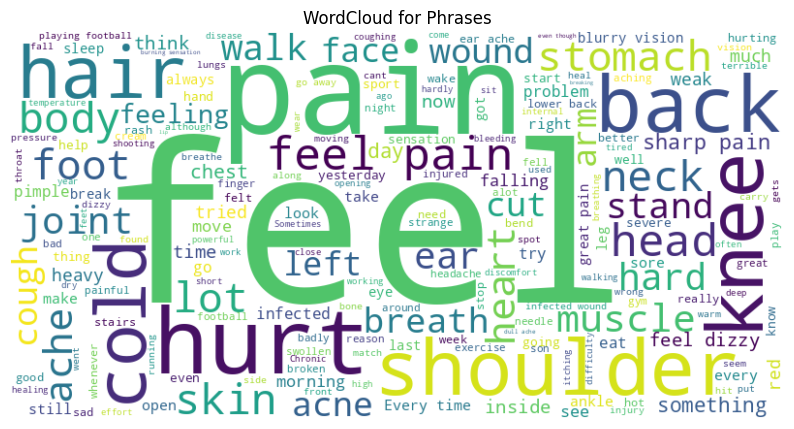

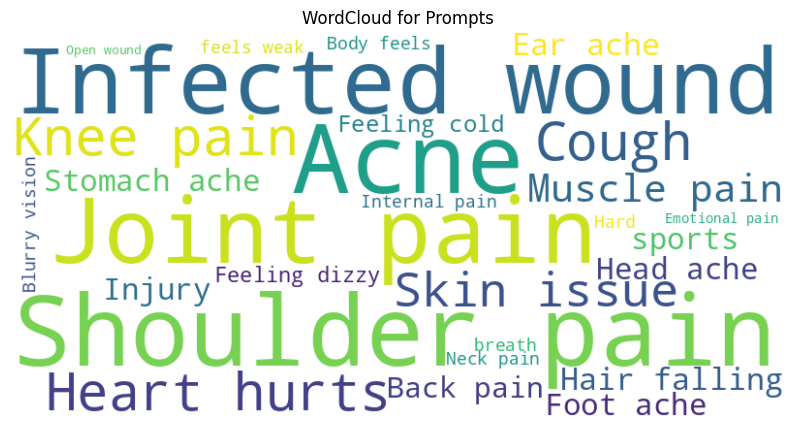

In [ ]:
# Concatenate all text from 'prompts' column into a single string
all_prompts = ' '.join(df['prompt'])

# Concatenate all text from 'phrases' column into a single string
all_phrases = ' '.join(df['phrase'])

# Create a WordCloud object for prompts
wordcloud_prompts = WordCloud(width=800, height=400, background_color='white').generate(all_prompts)

# Create a WordCloud object for phrases
wordcloud_phrases = WordCloud(width=800, height=400, background_color='white').generate(all_phrases)

# Plot WordCloud for phrases
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_phrases, interpolation='bilinear')
plt.title('WordCloud for Phrases')
plt.axis('off')
plt.show()

# Plot WordCloud for prompts
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_prompts, interpolation='bilinear')
plt.title('WordCloud for Prompts')
plt.axis('off')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Extract 'phrase' column as X and 'prompt' column as y
X = df['phrase']
y = df['prompt']

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optionally, you can convert X_train, X_test, y_train, y_test to lists if needed
X_train = X_train.tolist()
X_test = X_test.tolist()
y_train = y_train.tolist()
y_test = y_test.tolist()


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score

# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Train the model (fine-tuning)

# Generate embeddings for training and testing data
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# Perform classification (example: using logistic regression)
from sklearn.linear_model import LogisticRegression

# Train a logistic regression classifier on the training embeddings
classifier = LogisticRegression()
classifier.fit(X_train_embeddings, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Accuracy: 0.8309859154929577


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Train the model (fine-tuning)

# Generate embeddings for training and testing data
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# Perform classification (example: using logistic regression)
from sklearn.linear_model import LogisticRegression

# Train a logistic regression classifier on the training embeddings
classifier = SVC(kernel='linear')
classifier.fit(X_train_embeddings, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8450704225352113


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Train the model (fine-tuning)

# Generate embeddings for training and testing data
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# Perform classification (example: using logistic regression)
classifier = GradientBoostingClassifier()
classifier.fit(X_train_embeddings, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5563380281690141


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Train the model (fine-tuning)

# Generate embeddings for training and testing data
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# Perform classification (example: using logistic regression)
classifier = KNeighborsClassifier()
classifier.fit(X_train_embeddings, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7816901408450704


In [ ]:
# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Generate embeddings for training and testing data
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# Perform classification (example: using logistic regression)
from sklearn.linear_model import LogisticRegression

# Train a logistic regression classifier on the training embeddings
classifier = SVC(kernel='poly')
classifier.fit(X_train_embeddings, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8309859154929577


In [ ]:
# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Generate embeddings for training and testing data
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# Perform classification (example: using logistic regression)
from sklearn.linear_model import LogisticRegression

# Train a logistic regression classifier on the training embeddings
classifier = SVC(kernel='rbf')
classifier.fit(X_train_embeddings, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8450704225352113


In [ ]:
# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Generate embeddings for training and testing data
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# Perform classification (example: using logistic regression)
from sklearn.linear_model import LogisticRegression

# Train a logistic regression classifier on the training embeddings
classifier = SVC(kernel='sigmoid')
classifier.fit(X_train_embeddings, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8380281690140845


In [ ]:
# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Generate embeddings for training and testing data
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# Perform classification (example: using logistic regression)
from sklearn.linear_model import LogisticRegression

# Train a logistic regression classifier on the training embeddings
classifier = SVC(kernel='linear')
classifier.fit(X_train_embeddings, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8450704225352113


In [ ]:
# Embedding the New Phrase
new_phrase = "My knees hurt when I walk"
new_phrase_embedding = model.encode([new_phrase])

# Predicting the Prompt
predicted_prompt = classifier.predict(new_phrase_embedding)

# Calculating Cosine Similarity Score
cosine_sim_scores = cosine_similarity(new_phrase_embedding, X_train_embeddings[y_train == predicted_prompt])

print("Predicted Prompt:", predicted_prompt)
print("Cosine Similarity Scores:", cosine_sim_scores)

Predicted Prompt: ['Knee pain']
Cosine Similarity Scores: [[0.8758294  0.67635274 0.19791728 0.89050937 0.8162867  0.89500666
  0.76094633 0.53676164 0.70246255 0.6152164  0.73802996 0.7422489
  0.6666902  0.619732   0.7894813  0.6334759  0.821614   0.62592643
  0.6353826  0.5711572  0.32461846 0.6495409  0.6135975  0.70240116
  0.63282394 0.782934   0.681852  ]]


In [ ]:
# Embedding the New Phrase
new_phrase = "Can't sleep, feeling restless and sore"
new_phrase_embedding = model.encode([new_phrase])

# Predicting the Prompt
predicted_prompt = classifier.predict(new_phrase_embedding)

# Calculating Cosine Similarity Score
cosine_sim_scores = cosine_similarity(new_phrase_embedding, X_train_embeddings[y_train == predicted_prompt])

print("Predicted Prompt:", predicted_prompt)
print("Cosine Similarity Scores:", cosine_sim_scores)

Predicted Prompt: ['Internal pain']
Cosine Similarity Scores: [[0.35045272 0.44268048 0.3575212  0.24157622 0.28368035 0.40929663
  0.39395624 0.3661657  0.35405797 0.43770757 0.32745406 0.43000817
  0.3311047  0.31048793 0.3028478  0.3652474  0.20889726 0.20842907
  0.24915227 0.23357235 0.4567626  0.19447342 0.3685158  0.40127873]]


In [ ]:
# Prepare the new phrase and prompt
new_phrase = "Can't sleep, feeling restless and sore"
new_prompt = "Muscle pain"

# Encode the new phrase
new_phrase_embedding = model.encode([new_phrase])

# Append the new phrase embedding and prompt to the training data
X_train_updated = np.vstack([X_train_embeddings, new_phrase_embedding])
y_train_updated = np.append(y_train, new_prompt)

# Retrain the logistic regression classifier with the updated data
classifier.fit(X_train_updated, y_train_updated)

SVC(kernel='linear')

In [ ]:
# Embedding the New Phrase
new_phrase = "Can't sleep, feeling restless and sore"
new_phrase_embedding = model.encode([new_phrase])

# Predicting the Prompt
predicted_prompt = classifier.predict(new_phrase_embedding)

# Calculating Cosine Similarity Score
cosine_sim_scores = cosine_similarity(new_phrase_embedding, X_train_embeddings[y_train == predicted_prompt])

print("Predicted Prompt:", predicted_prompt)
print("Cosine Similarity Scores:", cosine_sim_scores)

Predicted Prompt: ['Muscle pain']
Cosine Similarity Scores: [[0.33060843 0.29553515 0.40371913 0.19610763 0.41191608 0.21667677
  0.26539183 0.30351162 0.32424736 0.29817683 0.2943635  0.29139632
  0.332808   0.29144514 0.3795673  0.2842089  0.29908016 0.38060242
  0.30914843 0.21496208 0.41996622 0.33605415 0.310982   0.25634494]]


In [ ]:
# Embedding the New Phrase
new_phrase = "Trouble sleeping, aching and restless"
new_phrase_embedding = model.encode([new_phrase])

# Predicting the Prompt
predicted_prompt = classifier.predict(new_phrase_embedding)

# Calculating Cosine Similarity Score
cosine_sim_scores = cosine_similarity(new_phrase_embedding, X_train_embeddings[y_train == predicted_prompt])

print("Predicted Prompt:", predicted_prompt)
print("Cosine Similarity Scores:", cosine_sim_scores)

Predicted Prompt: ['Muscle pain']
Cosine Similarity Scores: [[0.25833184 0.3001265  0.39477873 0.19429708 0.45523387 0.2652372
  0.2674355  0.30636024 0.31898963 0.32418948 0.31641138 0.3182832
  0.34198207 0.260531   0.34596306 0.29311144 0.29319805 0.34676233
  0.30278128 0.25049973 0.35927463 0.29422244 0.24775904 0.2272816 ]]
